# Rigorous Fine-Tuning of the Embedding Model

This notebook trains our semantic search model (`all-MiniLM-L6-v2`) to better understand the relationship between developer questions and raw code.

We use **Multiple Negatives Ranking Loss (MNRL)**. To ensure the model doesn't overfit, we split the data into **Train**, **Validation**, and **Test** sets. We evaluate the model continually during training using Mean Reciprocal Rank (MRR@10) and plot the learning curve automatically.

In [ ]:
import os
import ast
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator

print("Required ML dependencies imported successfully!")

## 1. Load the Generated Dataset

In [ ]:
dataset_path = 'training_data.jsonl'
data = []

with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"Loaded {len(df)} total dataset pairs.")

## 2. Train / Validation / Test Splits
We hold out 20% of the data (split equally into validation and testing).

In [ ]:
# 80% Train, 20% Temp (Val/Test)
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42)
# 10% Validation, 10% Test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(f"Training set: {len(df_train)} pairs")
print(f"Validation set: {len(df_val)} pairs")
print(f"Test set: {len(df_test)} pairs")

## 3. Prepare Dataloaders & Evaluators
We wrap the training data in `InputExample` objects for MNRL, and prepare an `InformationRetrievalEvaluator` for the validation set.

In [ ]:
# 3A. Train Dataloader
train_examples = []
for _, row in df_train.iterrows():
    train_examples.append(InputExample(texts=[row['question'], row['code']]))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8, num_workers=0)

# 3B. Validation Evaluator
val_queries, val_corpus, val_relevant_docs = {}, {}, {}
for i, row in df_val.iterrows():
    q_id = f"q_{i}"
    c_id = f"c_{i}"
    val_queries[q_id] = row['question']
    val_corpus[c_id] = row['code']
    val_relevant_docs[q_id] = [c_id]

val_evaluator = InformationRetrievalEvaluator(
    queries=val_queries,
    corpus=val_corpus,
    relevant_docs=val_relevant_docs,
    name="explainer-val-set",
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 5, 10],
    show_progress_bar=False
)

print("Dataloaders and evaluators configured.")

## 4. Initialize Model & Loss

In [ ]:
model_name = 'all-MiniLM-L6-v2'
print(f"Loading base model: {model_name}")
model = SentenceTransformer(model_name)

# Define the MNRL objective
train_loss = losses.MultipleNegativesRankingLoss(model=model)

## 5. Train the Model
We evaluate continuously so we can generate visual graphs of its learning process.

In [ ]:
num_epochs = 4
warmup_steps = int(len(train_dataloader) * num_epochs * 0.1)
output_dir = '../models/finetuned-explainer-model'

# Evaluate frequently relative to our dataset size
evaluation_steps = max(1, len(train_dataloader) // 2)

print(f"Starting training for {num_epochs} epochs...")
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    evaluator=val_evaluator,
    evaluation_steps=evaluation_steps,
    output_path=output_dir,
    show_progress_bar=False
)

print(f"Training complete! Model successfully saved to {output_dir}")

## 6. Visualize Training Metrics
During training, Sentence Transformers writes the evaluator results to a CSV inside the model directory. We can plot MRR (Mean Reciprocal Rank) to prove the model improved.

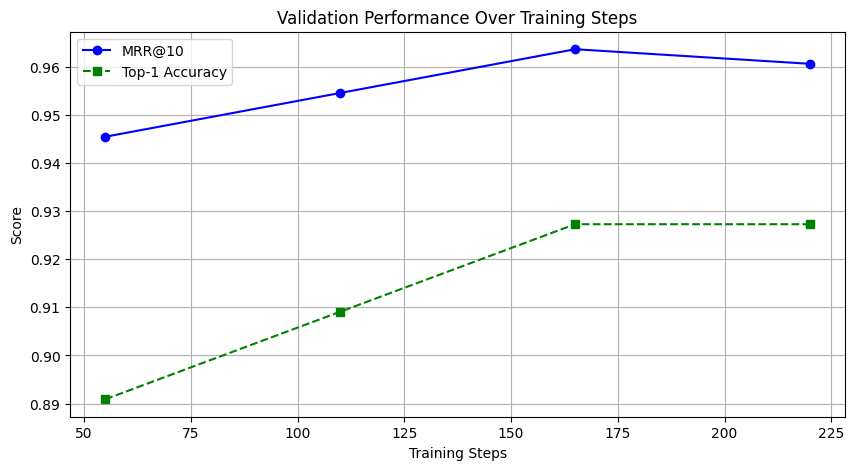

In [8]:
csv_path = os.path.join(output_dir, 'eval', 'Information-Retrieval_evaluation_explainer-val-set_results.csv')

if os.path.exists(csv_path):
    eval_df = pd.read_csv(csv_path)
    
    plt.figure(figsize=(10, 5))
    plt.plot(eval_df['steps'], eval_df['cosine-MRR@10'], marker='o', linestyle='-', color='b', label='MRR@10')
    plt.plot(eval_df['steps'], eval_df['cosine-Accuracy@1'], marker='s', linestyle='--', color='g', label='Top-1 Accuracy')
    
    plt.title('Validation Performance Over Training Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Could not find evaluation CSV for plotting.")

## 7. Interactive Test on Holdout Set
Let's test the newly fine-tuned model against the Test Set it has NEVER seen!

In [11]:
import numpy as np
from sentence_transformers import util

print("--- SIMULATING A REAL SEARCH USING TEST SET ---")

# 1. Embed all test corpus code blocks
test_corpus_codes = df_test['code'].tolist()
print(f"Embedding {len(test_corpus_codes)} unseen code snippets...")
corpus_embeddings = model.encode(test_corpus_codes, convert_to_tensor=True)

# 2. Pick a random test question
sample_row = df_test.sample(1).iloc[0]
test_question = sample_row['question']
real_answer_code = sample_row['code']

print(f"\n🔎 USER ASKS: \"{test_question}\"")

# 3. Embed the question and search
query_embedding = model.encode(test_question, convert_to_tensor=True)
hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=3)[0]

# 4. Check results
print("\n🏆 Top Retrieved Match:")
top_match_code = test_corpus_codes[hits[0]['corpus_id']]
print(top_match_code[:200] + " [...]\n")

if top_match_code == real_answer_code:
    print("✅ SUCCESS! The model successfully retrieved the EXACT right code chunk for this question.")
else:
    print("❌ FAILED. It retrieved something else.")


--- SIMULATING A REAL SEARCH USING TEST SET ---
Embedding 55 unseen code snippets...

🔎 USER ASKS: "How to pass data to a Go concurrent worker?"

🏆 Top Retrieved Match:
package main
import (
  "fmt"
)
type Worker struct {
  data chan string
}
func (w *Worker) worker() {
  for data := range w.data {
    fmt.Println(data)
  }
}
func main() {
  var w = &Worker{
    data [...]

✅ SUCCESS! The model successfully retrieved the EXACT right code chunk for this question.
